<h1><center>TYPE 1 - TRAINING MODEL WITHOUT REDUCING THE DIMENSION</h1></center>

<h3>STEP 1 - Loading Dataset</h3>

In [10]:
import pandas as pd

data = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_03\cicids2017_merged.csv')

X = data.drop("Encoded_Label", axis=1)
y = data["Encoded_Label"]

print("Dataset shape:", data.shape)

Dataset shape: (2520751, 81)


<h3>STEP 2 - Scaling</h3>

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\scaler_bilstm.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP 3 - Train / Val / Test Split</h3>

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

<h3>STEP - 4 Class Weights (Clamp Again)</h3>

In [13]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

# Clamp extreme weights
class_weights_dict = {
    k: min(v, 30)   # Slightly lower than RNN
    for k, v in class_weights_dict.items()
}

print(class_weights_dict)

{0: np.float64(0.17188427992709365), 1: 30, 2: 30, 3: np.float64(2.8130231001004353), 4: np.float64(1.8586723295064924), 5: np.float64(3.9705604385218787), 6: 30}


<h3>STEP - 5 Reshape for BiLSTM</h3>

In [14]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

<h3>STEP 6 - Build BiLSTM Model</h3>

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 7

model = Sequential([
    Input(shape=(78,1)),
    
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,503 (166.03 KB)

 Trainable params: 42,503 (166.03 KB)

 Non-trainable params: 0 (0.00 B)

<h3>STEP - 7 Callbacks</h3>

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

<h3>STEP - 8 Train BiLSTM</h3>

In [17]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 343s 197ms/step - accuracy: 0.7681 - loss: 0.3803 - val_accuracy: 0.9066 - val_loss: 0.3501 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 343s 199ms/step - accuracy: 0.8894 - loss: 0.1403 - val_accuracy: 0.8817 - val_loss: 0.2773 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 338s 196ms/step - accuracy: 0.9041 - loss: 0.1114 - val_accuracy: 0.9305 - val_loss: 0.2112 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 370s 215ms/step - accuracy: 0.9093 - loss: 0.1024 - val_accuracy: 0.9372 - val_loss: 0.1851 - learning_rate: 5.0000e-04
Epoch 5/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 367s 213ms/step - accuracy: 0.9174 - loss: 0.0902 - val_accuracy: 0.9409 - val_loss: 0.1749 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 343s 199ms/step - accuracy: 0.9216 - loss: 0.0852 - val_accuracy: 0.9416 - val_loss: 0.1637 - learning_rate: 5.0000e-04
Epoch 7/15
1724/1724 ━━━━━━━

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 90s 8ms/step - accuracy: 0.9489 - loss: 0.1432
Test Accuracy: 0.9489147663116455


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, batch_size=1024)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 35s 93ms/step
              precision    recall  f1-score   support

           0     0.9993    0.9397    0.9686    314259
           1     0.1029    0.7842    0.1819       292
           2     0.5376    0.9738    0.6927      1373
           3     0.8717    0.9986    0.9309     19202
           4     0.8119    0.9943    0.8938     29062
           5     0.7290    0.9971    0.8423     13604
           6     0.1773    0.9377    0.2982       321

    accuracy                         0.9489    378113
   macro avg     0.6042    0.9465    0.6869    378113
weighted avg     0.9656    0.9489    0.9542    378113



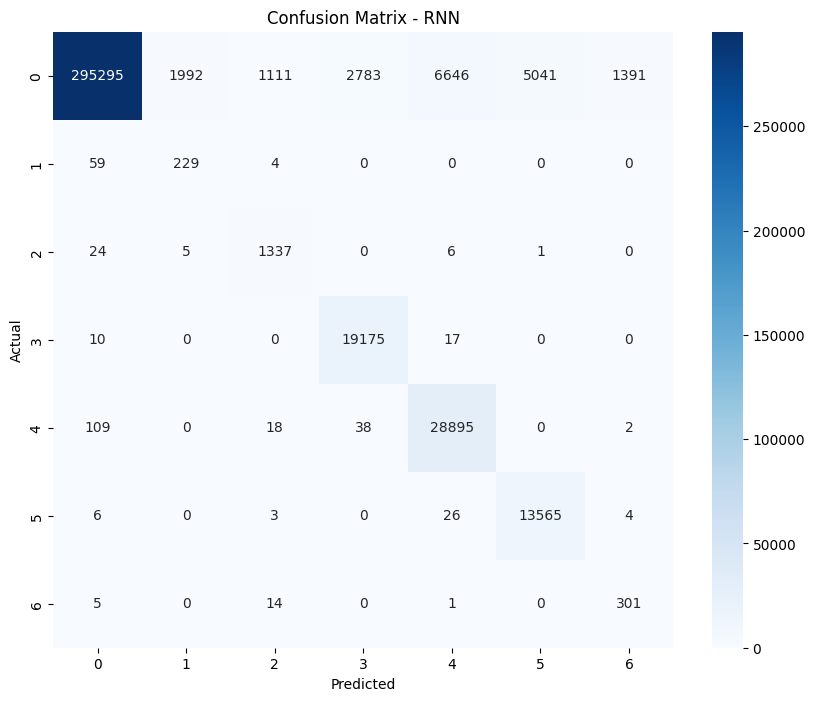

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

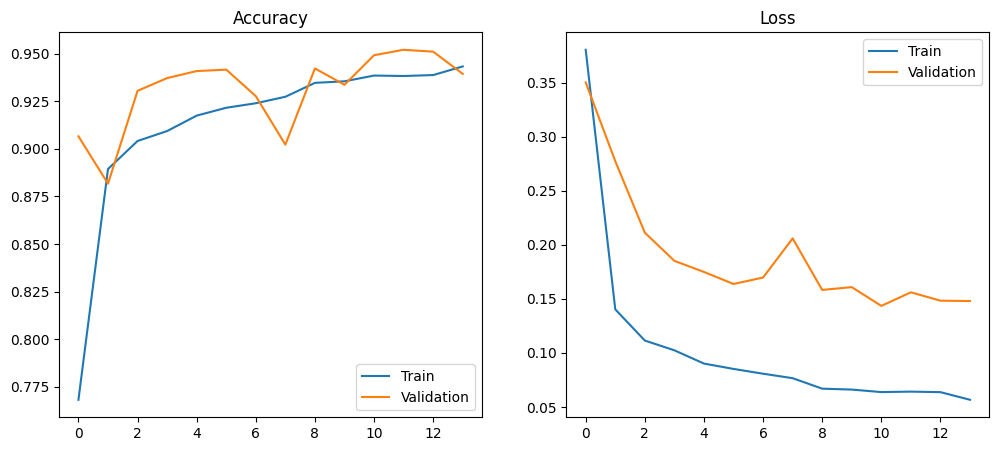

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [22]:
# Save in legacy HDF5 format
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\bilstm_model.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\bilstm_model.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.


<h1><center>TYPE 2 - TRAINING MODEL WITH SELECTED TOP 35 FEATURES</h1></center>

<h3>STEP 1 - Load Dataset</h3>

In [23]:
import pandas as pd

data_top_sec = pd.read_csv(r'D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\Data\processed_04\cicids2017_selected_top_features.csv')

print(data_top_sec.shape)

(2520751, 36)


</h3>STEP 2 – Separate X and y</h3>

In [24]:
X = data_top_sec.drop('Encoded_Label', axis=1)
y = data_top_sec['Encoded_Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2520751, 35)
y shape: (2520751,)


<h3>STEP 3 – Scale (float32 for memory efficiency)</h3>

In [25]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

# Ensure X only contains numeric features
X = X.select_dtypes(include=[np.number]).astype(np.float32)

# Fit and transform with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use
joblib.dump(scaler, r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\scaler_bilstm_top_features.pkl")

print("Scaling complete. Scaler saved successfully.")

Scaling complete. Scaler saved successfully.


<h3>STEP 4 – Train / Validation / Test Split</h3>

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1764525, 35)
Validation: (378113, 35)
Test: (378113, 35)


<h3>STEP 5 – Compute & Clamp Class Weights</h3>

In [27]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Reshaped Train:", X_train.shape)

Reshaped Train: (1764525, 35, 1)


<h3>STEP 7 - Build RNN with input shape of 35</h3>

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 7

model = Sequential([
    Input(shape=(35,1)),
    
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005,
    clipnorm=1.0
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,503 (166.03 KB)

 Trainable params: 42,503 (166.03 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [30]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=1024,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 169s 97ms/step - accuracy: 0.7797 - loss: 0.4114 - val_accuracy: 0.8641 - val_loss: 0.4629 - learning_rate: 5.0000e-04
Epoch 2/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 168s 97ms/step - accuracy: 0.8758 - loss: 0.2028 - val_accuracy: 0.8988 - val_loss: 0.2830 - learning_rate: 5.0000e-04
Epoch 3/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 167s 97ms/step - accuracy: 0.8933 - loss: 0.1708 - val_accuracy: 0.9050 - val_loss: 0.2607 - learning_rate: 5.0000e-04
Epoch 4/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 167s 97ms/step - accuracy: 0.8978 - loss: 0.1529 - val_accuracy: 0.8837 - val_loss: 0.3045 - learning_rate: 5.0000e-04
Epoch 5/15
1723/1724 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9014 - loss: 0.1418
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1724/1724 ━━━━━━━━━━━━━━━━━━━━ 167s 97ms/step - accuracy: 0.9037 - loss: 0.1399 - val_accuracy: 0.9065 - val_loss: 0.2622 - learning_rate: 5.0000e-04
Epoch 6/15
1724/1724 ━━━━━━━━━━━━━━━━━━━━

<h3>STEP 8 - BILSTM EVALUATION</h3>

In [31]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

11817/11817 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - accuracy: 0.9375 - loss: 0.1678
Test Accuracy: 0.9375160336494446


In [32]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test, batch_size=1024)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred_classes, digits=4))

370/370 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step
              precision    recall  f1-score   support

           0     0.9987    0.9268    0.9614    314259
           1     0.0521    0.9212    0.0986       292
           2     0.5105    0.9760    0.6703      1373
           3     0.8439    0.9974    0.9143     19202
           4     0.8250    0.9845    0.8977     29062
           5     0.6938    0.9973    0.8183     13604
           6     0.1706    0.9408    0.2889       321

    accuracy                         0.9375    378113
   macro avg     0.5849    0.9634    0.6642    378113
weighted avg     0.9633    0.9375    0.9467    378113



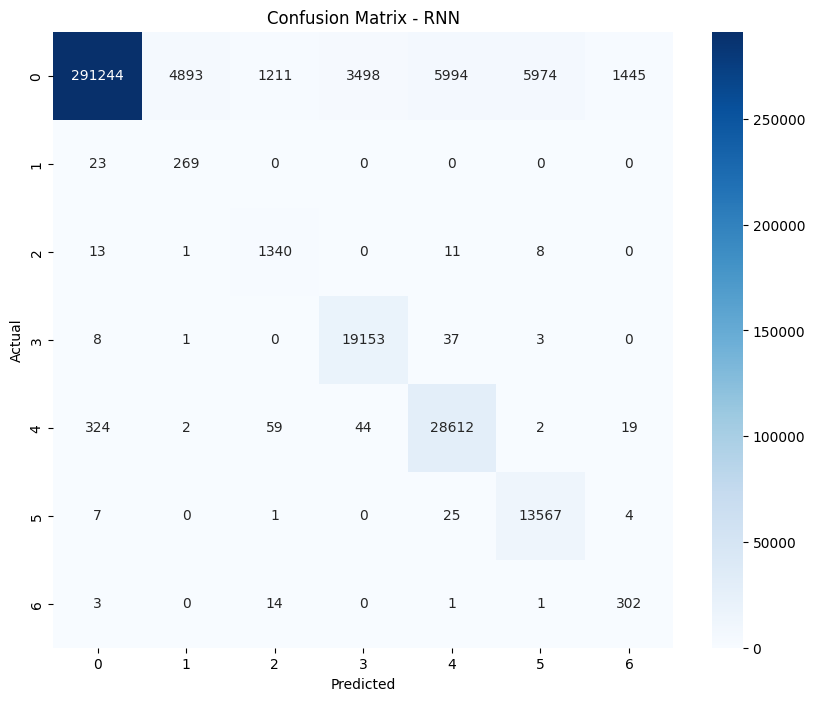

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

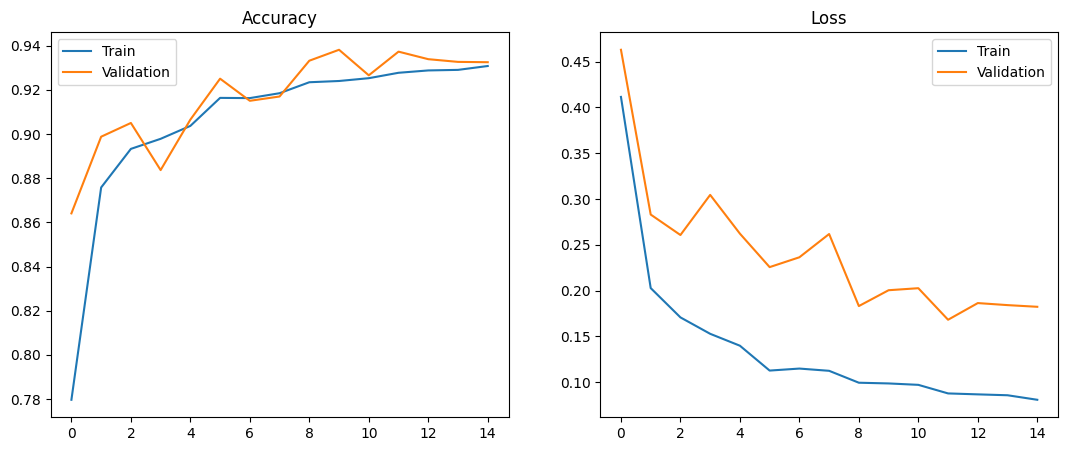

In [40]:
plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [41]:
# Save in legacy HDF5 format
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\bilstm_model_top_features.h5")

# Save in native Keras format (recommended)
model.save(r"D:\My_Space\College\6th_SEM\Deep_Learning_Project\IDS\models\bilstm\bilstm_model_top_features.keras")

print("Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.")

Model saved successfully in both HDF5 (.h5) and Keras (.keras) formats.
